## Import libraries

In [1]:
import tomopy
from helperFunctions import MoviePlotter
from tomoDataClass import tomoData
from alignment_methods import sinogram_consistency_score, reconstruction_sharpness_score

## Create Simulated Data

In [2]:
#Set constants
numAngles = 200 #Number of projection angles
imageSize = 256 #Pixel size of one side of cubic array containing Shepp3D phantom

In [3]:
#Create a simulated object
obj = tomopy.shepp3d(size=imageSize)
print(obj.shape)
print("Simulated Object")
MoviePlotter(obj) #Plots vertical slices through the phantom

(256, 256, 256)
Simulated Object


Output()

In [4]:
# Set projection angles
angles = tomopy.angles(nang=numAngles, ang1=1, ang2=180)

# create projection images/sinogram
projections = tomopy.project(obj, angles, pad=False)

print("Projections through object")
MoviePlotter(projections)

Projections through object


Output()

In [5]:
tomo = tomoData(projections, angles)
tomo.jitter(maxShift = 6)
# tomo.add_noise()
print("Projections through Object with jitter and noise")

tomo.data = -tomo.data[::,0:imageSize//2] #Invert the data to make it look more like real projections
tomo.reset_workingProjections()
tomo.makeNotebookProjMovie()

Projections through Object with jitter and noise


Output()

## Align Data

In [6]:
#Show bad reconstruction prior to alignment
tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize) #You can adjust these for tighter cropping
tomo.normalize(isPhaseData=True)

tomo.reconstruct(algorithm='art')
print("\nBad reconstruction prior to alignment")
badRecon = tomo.recon.copy()
MoviePlotter(badRecon)



Normalizing projections


Using CPU-based reconstruction. Algorithm:  art
Reconstruction completed.

Bad reconstruction prior to alignment


Output()

Sinogram consistency:
  x_cm (horizontal) — RMSE: 3.1762 px  |  R²: 0.269220
  y_cm (vertical)   — RMSE: 1.6011 px  |  R²: 0.000000
  Combined RMSE:       2.5151 px


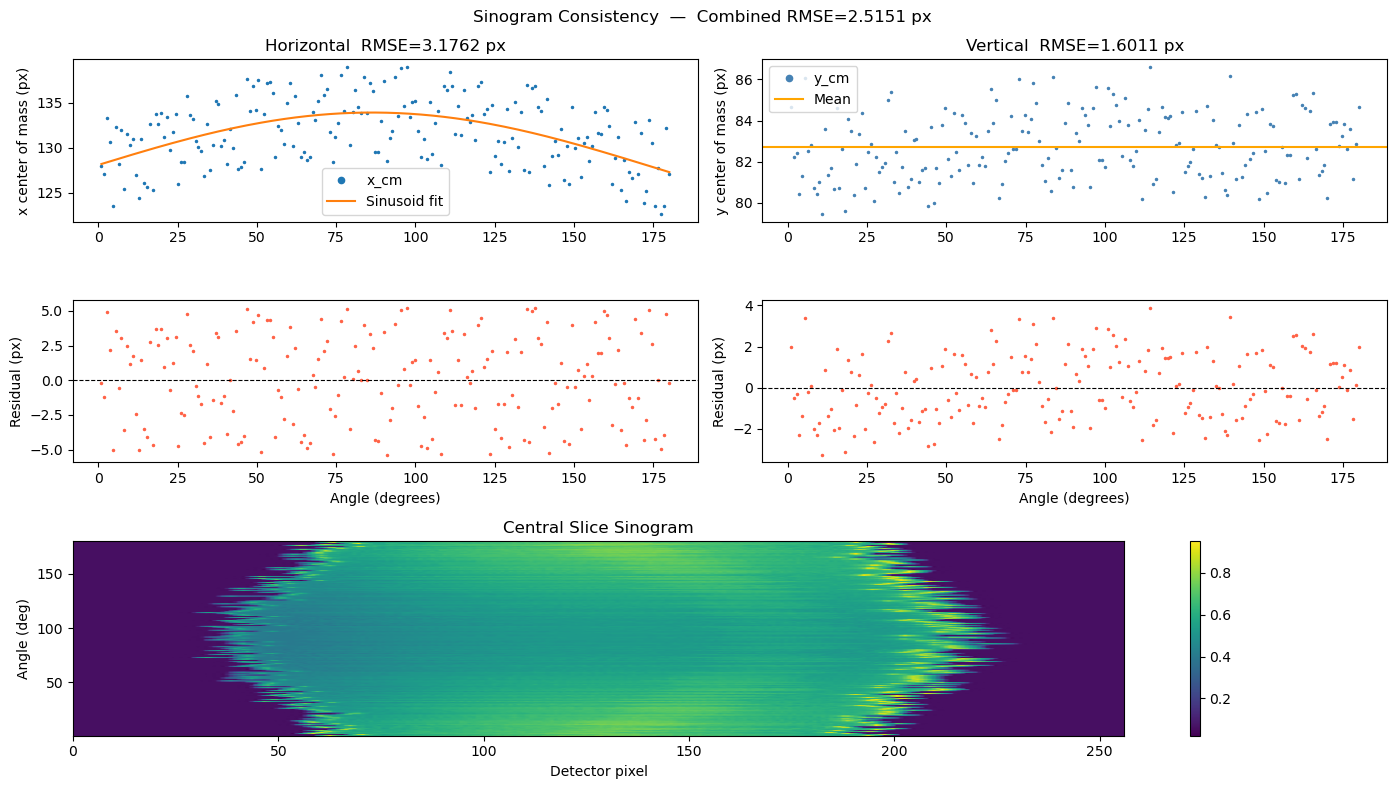

Reconstruction sharpness:
  Mean gradient magnitude: 0.039904
  Laplacian variance:      0.060569


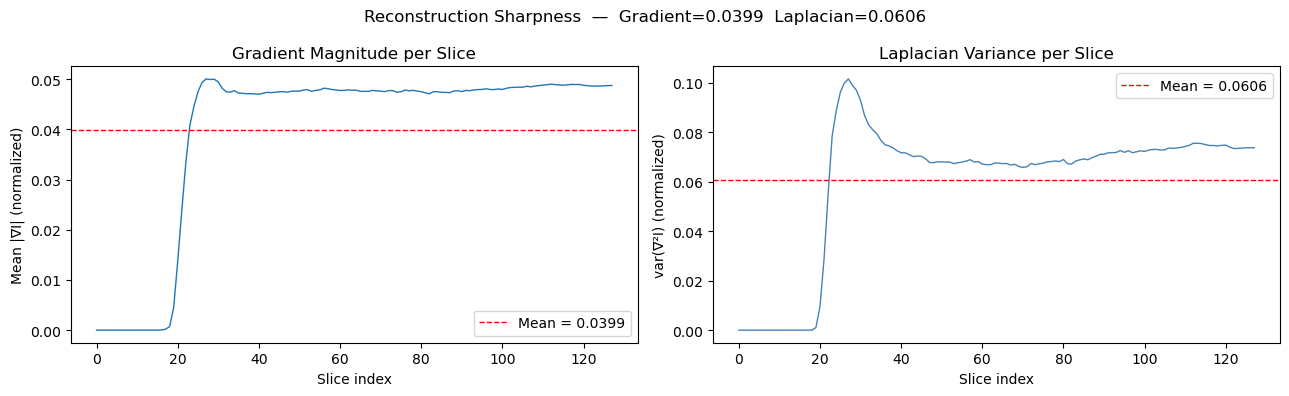


Baseline  →  Gradient: 0.039904  |  Laplacian: 0.060569


In [7]:
# Sinogram consistency score — before alignment
combined_rmse_before, x_rmse_before, y_rmse_before, _, _ = sinogram_consistency_score(tomo, plot=True)

# Baseline sharpness — before alignment
grad_before, lap_before, _, _ = reconstruction_sharpness_score(badRecon, plot=True, percentile_crop=5)
print(f"\nBaseline  →  Gradient: {grad_before:.6f}  |  Laplacian: {lap_before:.6f}")

In [8]:

# # ── VMF Parameter Search ─────────────────────────────────────────────────────
# # Sweeps sigma, smooth_sigma, window, roi_sigma, and use_gradient.
# # Uses max_iterations=5 per run; swap algorithm to 'gridrec' for a faster sweep.
# import itertools
# import pandas as pd
# from tqdm.notebook import tqdm as tqdm_nb

# RECON_ALG    = 'art'   # change to 'gridrec' or 'fbp' for a much faster sweep
# MAX_ITER_VMF = 10

# sigmas        = [None, 1.0, 2.0, 3.0, 4.0]        # None → auto (image_height / 128)
# smooth_sigmas = [1.0]
# windows       = ['soft_roi']
# roi_sigmas    = [0.3]         # only active when window='soft_roi'
# use_gradients = [True]

# # Build config list: roi_sigma only varies for soft_roi; fix it at 0.3 otherwise
# configs = []
# for use_gradient, window, sigma, smooth_sigma in itertools.product(
#         use_gradients, windows, sigmas, smooth_sigmas):
#     if window == 'soft_roi':
#         for roi_sigma in roi_sigmas:
#             configs.append(dict(sigma=sigma, smooth_sigma=smooth_sigma,
#                                 window=window, roi_sigma=roi_sigma,
#                                 use_gradient=use_gradient))
#     else:
#         configs.append(dict(sigma=sigma, smooth_sigma=smooth_sigma,
#                             window=window, roi_sigma=0.3,
#                             use_gradient=use_gradient))

# print(f"Configurations to test: {len(configs)}")

# # Seed the results table with the pre-alignment baseline
# rows = [dict(sigma='baseline', smooth_sigma='—', window='—', roi_sigma='—',
#              use_gradient='—', sino_rmse=combined_rmse_before,
#              grad=grad_before, lap=lap_before)]

# for cfg in tqdm_nb(configs, desc='VMF param search'):
#     tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize)
#     tomo.normalize(isPhaseData=True)

#     tomo.vertical_mass_fluctuation_align(
#         tolerance=0, max_iterations=MAX_ITER_VMF, y_range=None, plot=False, **cfg
#     )
#     tomo.make_updates_shift()
#     tomo.reconstruct(algorithm=RECON_ALG)

#     sino_rmse, _, _, _, _ = sinogram_consistency_score(tomo, plot=False)
#     grad, lap, _, _       = reconstruction_sharpness_score(tomo.recon, plot=False, percentile_crop=5)

#     rows.append({**cfg, 'sino_rmse': sino_rmse, 'grad': grad, 'lap': lap})

# # ── Results table ─────────────────────────────────────────────────────────────
# df = pd.DataFrame(rows)

# # Rank by sinogram RMSE (lower = better), then show sharpness scores (higher = better)
# df_sorted = df.sort_values('sino_rmse').reset_index(drop=True)
# df_sorted.index.name = 'rank'

# # Format floats for readability
# for col in ('sino_rmse', 'grad', 'lap'):
#     df_sorted[col] = df_sorted[col].apply(
#         lambda x: f'{x:.6f}' if isinstance(x, float) else x)

# print("\n── VMF Parameter Search Results (sorted by sinogram RMSE, lower = better) ──")
# print(df_sorted.to_string())




Normalizing projections


Cross-Correlation Alignment  [4x downsample | full frame | gradient mode]


Iteration 1/15: 100%|██████████| 199/199 [00:00<00:00, 378.96it/s]


Iteration 1: avg shift = 5.6157 px, max shift = 12.2042 px


Iteration 2/15: 100%|██████████| 199/199 [00:00<00:00, 407.18it/s]


Iteration 2: avg shift = 0.4715 px, max shift = 1.1526 px


...

Iteration 4/30: 100%|██████████| 199/199 [00:01<00:00, 162.04it/s]


Iteration 4: avg shift = 0.0004 px, max shift = 0.0400 px


Iteration 5/30: 100%|██████████| 199/199 [00:00<00:00, 335.03it/s]


Iteration 5: avg shift = 0.0000 px, max shift = 0.0000 px
Convergence reached after 5 iterations.


Projection Matching Alignment (PMA) [optical_flow]
Centering Projections
Original center: 127.5
Center of frame: 128
Aligned projections shifted by 0.5 pixels
Projections are currently centered at pixel 128.0. Residual offset: 0.0

--- PMA Level 2 (4x downsampled, 5 iterations) ---


PMA Level 2 iterations:   0%|          | 0/5 [00:00<?, ?it/s]

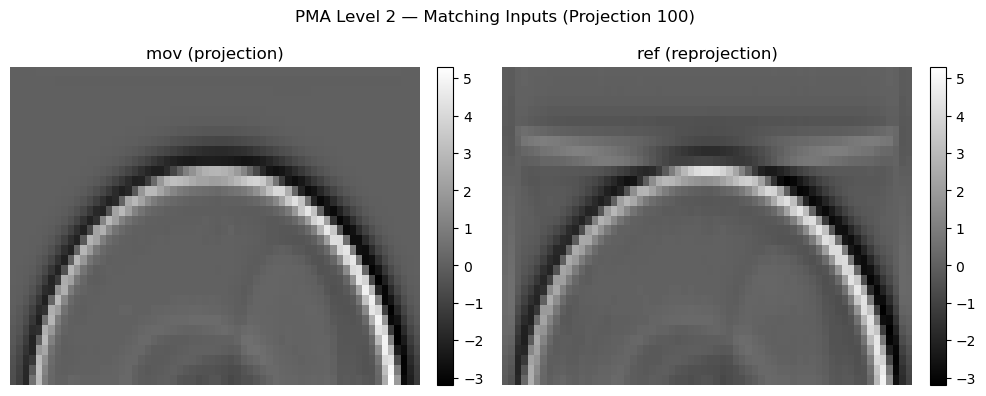

PMA Level 2 iterations:  20%|██        | 1/5 [00:06<00:27,  6.77s/it]

  Iter 1: avg=0.0561 px


PMA Level 2 iterations:  40%|████      | 2/5 [00:14<00:21,  7.31s/it]

  Iter 2: avg=0.0511 px


PMA Level 2 iterations:  60%|██████    | 3/5 [00:18<00:11,  5.78s/it]

...

PMA Level 2 iterations:  80%|████████  | 4/5 [00:23<00:05,  5.41s/it]

  Iter 4: avg=0.0489 px


PMA Level 2 iterations: 100%|██████████| 5/5 [00:27<00:00,  5.48s/it]

  Iter 5: avg=0.0482 px

--- PMA Level 1 (2x downsampled, 5 iterations) ---



PMA Level 1 iterations:   0%|          | 0/5 [00:00<?, ?it/s]

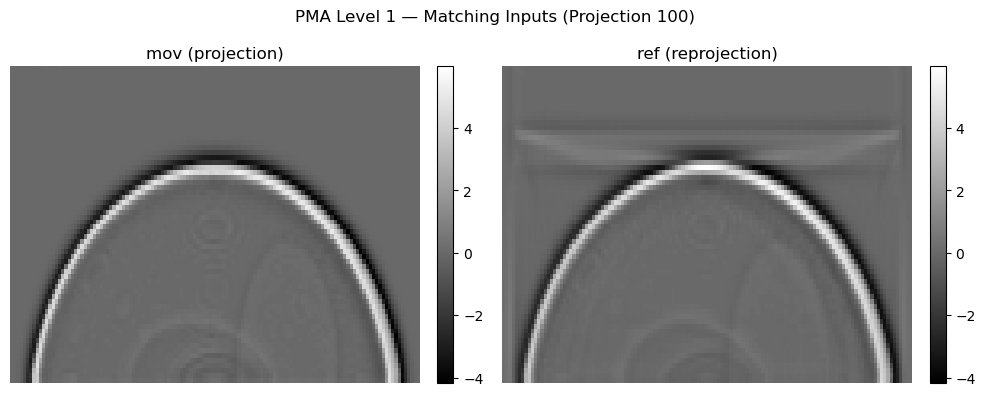

PMA Level 1 iterations:  20%|██        | 1/5 [00:10<00:42, 10.68s/it]

  Iter 1: avg=0.0571 px


PMA Level 1 iterations:  40%|████      | 2/5 [00:17<00:25,  8.59s/it]

  Iter 2: avg=0.0510 px


PMA Level 1 iterations:  60%|██████    | 3/5 [00:22<00:13,  6.85s/it]

...

PMA Level 1 iterations:  80%|████████  | 4/5 [00:26<00:05,  5.68s/it]

  Iter 4: avg=0.0476 px


PMA Level 1 iterations: 100%|██████████| 5/5 [00:30<00:00,  6.05s/it]

  Iter 5: avg=0.0465 px

--- PMA Level 0 (1x downsampled, 2 iterations) ---



PMA Level 0 iterations:   0%|          | 0/2 [00:00<?, ?it/s]

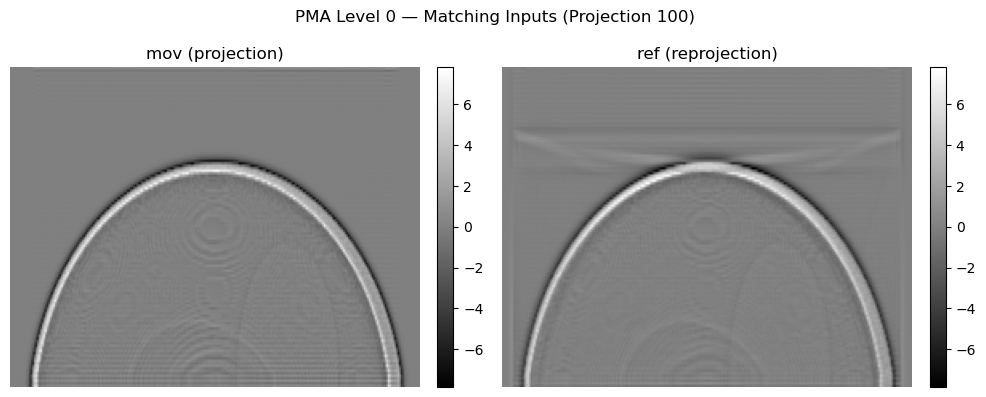

PMA Level 0 iterations:  50%|█████     | 1/2 [00:08<00:08,  8.48s/it]

  Iter 1: avg=0.0495 px


PMA Level 0 iterations: 100%|██████████| 2/2 [00:17<00:00,  8.72s/it]

  Iter 2: avg=0.0389 px



PMA complete.


Apply shifts to final projections: 100%|██████████| 200/200 [00:01<00:00, 193.49it/s]


In [12]:
tomo.reset_workingProjections(x_size=imageSize, y_size=imageSize)
tomo.normalize(isPhaseData=True)

#Best XC params from sweep:
# Coarse passes: stepRatio=0.9 (stable global convergence)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=15, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=4, use_grad=True)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=15, stepRatio=0.9, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=2, use_grad=True)
# Final pass: stepRatio=0.75-0.8 with more iterations (fine-scale sharpness)
tomo.cross_correlate_align(tolerance=0, maxShiftTolerance=0, max_iterations=30, stepRatio=0.8, yROI_Range=None, xROI_Range=None, isFull360=False, downsample=1, use_grad=True)


#Best VMF params from sweep:
# tomo.vertical_mass_fluctuation_align(tolerance=0, max_iterations=1, y_range=None, sigma=None, smooth_sigma=1.0, window='soft_roi', roi_sigma=0.3, use_gradient=True, plot=True)

tomo.PMA(max_iterations=5, tolerance=0, algorithm='art', levels=3, scale=2, iterations_per_level=[5,5,2], shift_method='optical_flow', of_sigma=3.0, plot=True)
tomo.make_updates_shift()

In [13]:
tomo.makeNotebookProjMovie()

tomo.reconstruct(algorithm='art')
print("\nGood Reconstruction after alignment")
tomo.makeNotebookReconMovie()

Output()



Using CPU-based reconstruction. Algorithm:  art
Reconstruction completed.

Good Reconstruction after alignment


Output()

Sinogram consistency:
  x_cm (horizontal) — RMSE: 0.3866 px  |  R²: 0.950919
  y_cm (vertical)   — RMSE: 2.2036 px  |  R²: 0.000000
  Combined RMSE:       1.5820 px


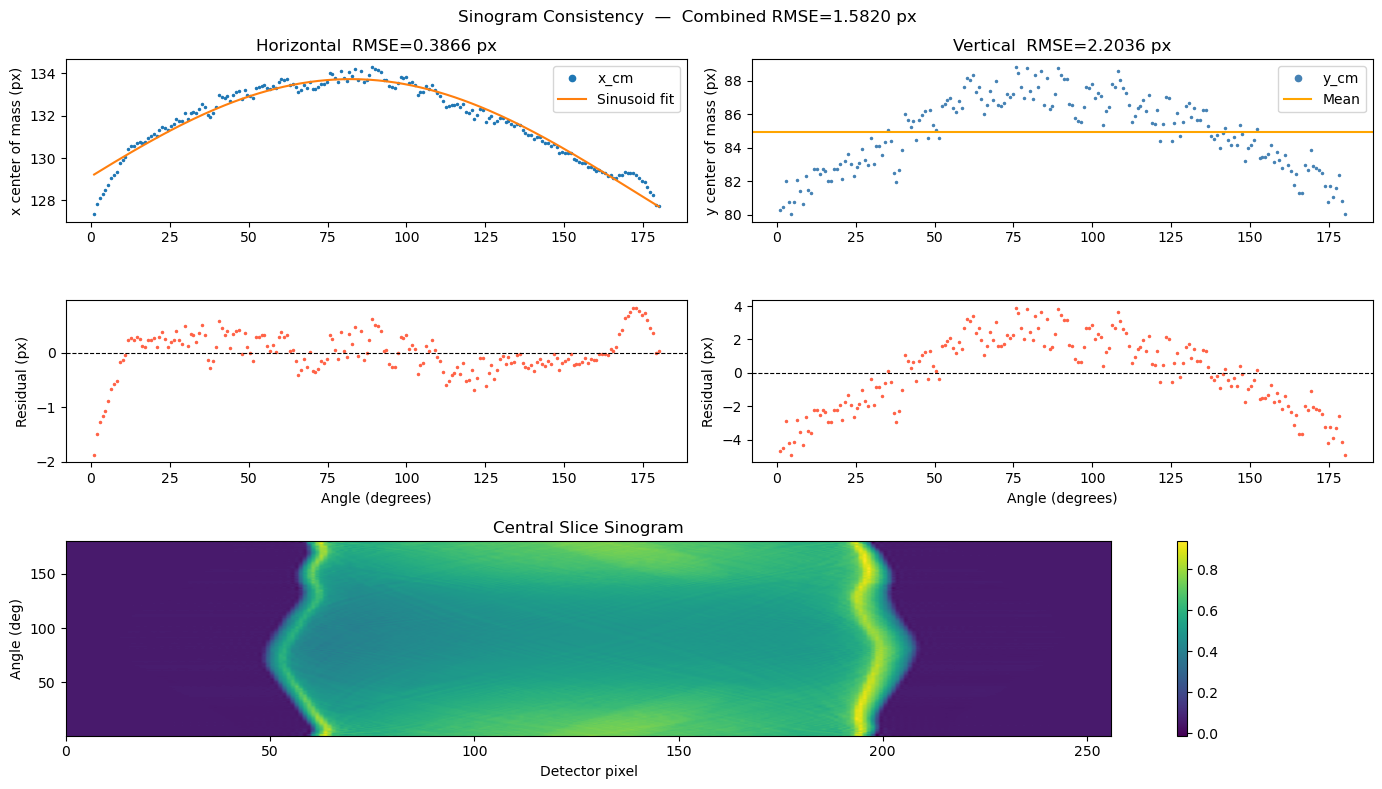

Reconstruction sharpness:
  Mean gradient magnitude: 0.016574
  Laplacian variance:      0.009245


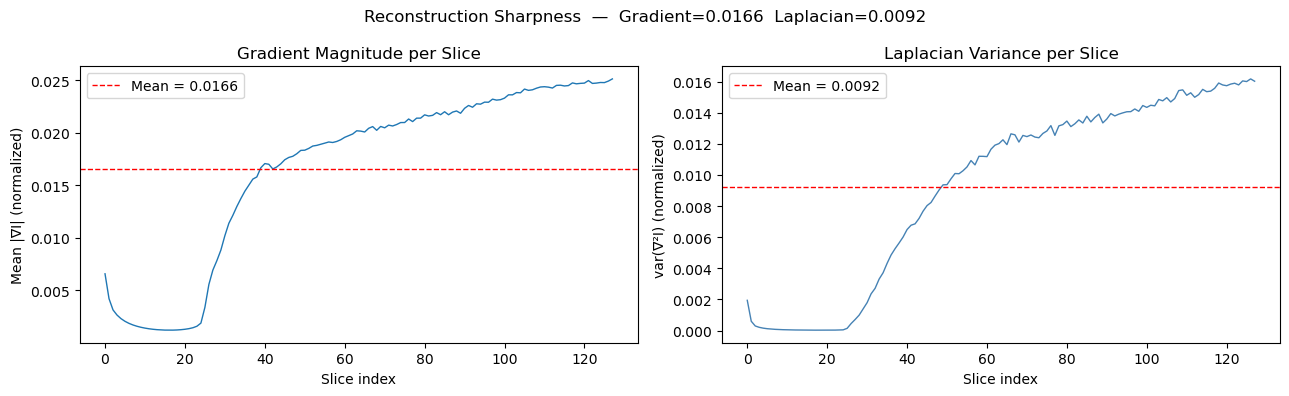

  ALIGNMENT QUALITY SUMMARY

Sinogram Consistency  (lower RMSE = better)
  Metric                     Before      After  Δ (improvement)
  ------------------------------------------------------------
  X RMSE (px)                3.1762     0.3866          +2.7896
  Y RMSE (px)                1.6011     2.2036          -0.6025
  Combined RMSE (px)         2.5151     1.5820          +0.9331

Reconstruction Sharpness
  Metric                     Before      After  Δ (improvement)
  ------------------------------------------------------------
  Gradient                 0.039904   0.016574        -0.023330
  Laplacian variance       0.060569   0.009245        -0.051324


In [14]:

# Sinogram consistency score — after alignment
combined_rmse_after, x_rmse_after, y_rmse_after, _, _ = sinogram_consistency_score(tomo, plot=True)

# Reconstruction sharpness score — after alignment
grad_after, lap_after, _, _ = reconstruction_sharpness_score(tomo.recon, plot=True, percentile_crop=5)

print("=" * 62)
print("  ALIGNMENT QUALITY SUMMARY")
print("=" * 62)
print(f"\n{'Sinogram Consistency  (lower RMSE = better)':}")
print(f"  {'Metric':<22} {'Before':>10} {'After':>10} {'Δ (improvement)':>16}")
print(f"  {'-'*60}")
print(f"  {'X RMSE (px)':<22} {x_rmse_before:>10.4f} {x_rmse_after:>10.4f} {x_rmse_before - x_rmse_after:>+16.4f}")
print(f"  {'Y RMSE (px)':<22} {y_rmse_before:>10.4f} {y_rmse_after:>10.4f} {y_rmse_before - y_rmse_after:>+16.4f}")
print(f"  {'Combined RMSE (px)':<22} {combined_rmse_before:>10.4f} {combined_rmse_after:>10.4f} {combined_rmse_before - combined_rmse_after:>+16.4f}")

print(f"\n{'Reconstruction Sharpness':}")
print(f"  {'Metric':<22} {'Before':>10} {'After':>10} {'Δ (improvement)':>16}")
print(f"  {'-'*60}")
print(f"  {'Gradient':<22} {grad_before:>10.6f} {grad_after:>10.6f} {grad_after - grad_before:>+16.6f}")
print(f"  {'Laplacian variance':<22} {lap_before:>10.6f} {lap_after:>10.6f} {lap_after - lap_before:>+16.6f}")
print("=" * 62)